In [1]:
library(tidyverse)

Warning message:
“package ‘dplyr’ was built under R version 4.2.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.3     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
C2specHubs_reg_genes <- readRDS('C2specHubs_reg_genes.Rds')
C3specHubs_reg_genes <- readRDS('C3specHubs_reg_genes.Rds')

In [3]:
length(C2specHubs_reg_genes)

[1] 3629

In [4]:
length(C3specHubs_reg_genes)

[1] 759

In [5]:
C2kegg <- readRDS('C2_isct_kegg.FC1.5.genebody.Rds')
C3kegg <- readRDS('C3_isct_kegg.FC1.5.genebody.Rds')

In [6]:
C2_epiReg <- readRDS('C2genesymbol_mergeGeneBody_HiChIP_isctRNAseq.Rds')
C3_epiReg <- readRDS('C3genesymbol_mergeGeneBody_HiChIP_isctRNAseq.Rds')

In [7]:
C2kegg  %>% as.data.frame()  %>% pull(geneID)  %>%   str_split('/')  %>% unlist() %>%
        unique()  -> C2kegggenes
C3kegg  %>% as.data.frame()  %>% pull(geneID)  %>%   str_split('/')  %>% unlist() %>%
        unique()  -> C3kegggenes

Loading required package: DOSE



DOSE v3.25.0.002  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use DOSE in published research, please cite:
Guangchuang Yu, Li-Gen Wang, Guang-Rong Yan, Qing-Yu He. DOSE: an R/Bioconductor package for Disease Ontology Semantic and Enrichment analysis. Bioinformatics 2015, 31(4):608-609




In [8]:
allgenes <- unique(c(C2_epiReg,C3_epiReg))

In [9]:
set.seed(123)
C2_random_save = c()
C3_random_save = c()
for(i in 1:1000){
    random_C2 <- sample(1:length(allgenes), 40)
    random_C3 <- sample(1:length(allgenes), 111)
    C2specHubs_reg_genes  %>% intersect(allgenes[random_C2]) -> C2_intersect
    C3specHubs_reg_genes  %>% intersect(allgenes[random_C3]) -> C3_intersect
    C2_random_save = c(C2_random_save,length(C2_intersect))
    C3_random_save = c(C3_random_save,length(C3_intersect))
}

In [10]:
length(C2specHubs_reg_genes);length(C3specHubs_reg_genes)

[1] 3629

[1] 759

In [11]:
C2specHubs_reg_genes  %>% intersect(C2kegggenes)   -> C2_intersect_genes
C3specHubs_reg_genes %>% intersect(C3kegggenes)   -> C3_intersect_genes

In [12]:
for(i in C2_intersect_genes){cat(i,"\n")}

ENO1 
GCLM 
ALDH3B1 
PKM 
ALDOA 
G6PC3 
BCAT2 
ACAA1 
PFKFB4 
GMPPB 
TKT 
DLD 


In [13]:
for(i in C3_intersect_genes){cat(i,"\n")}

DUSP16 
ERBB3 
FOS 
APC2 
JUND 
WNT4 
EGFR 
BMP8B 


In [14]:
z <- (length(C2_intersect_genes) - mean(C2_random_save)) / sd(C2_random_save)         # standardized value
pval <- 2 * (1 - pnorm(abs(z)))    # two-sided p-value
z; pval

[1] 1.027331

[1] 0.3042645

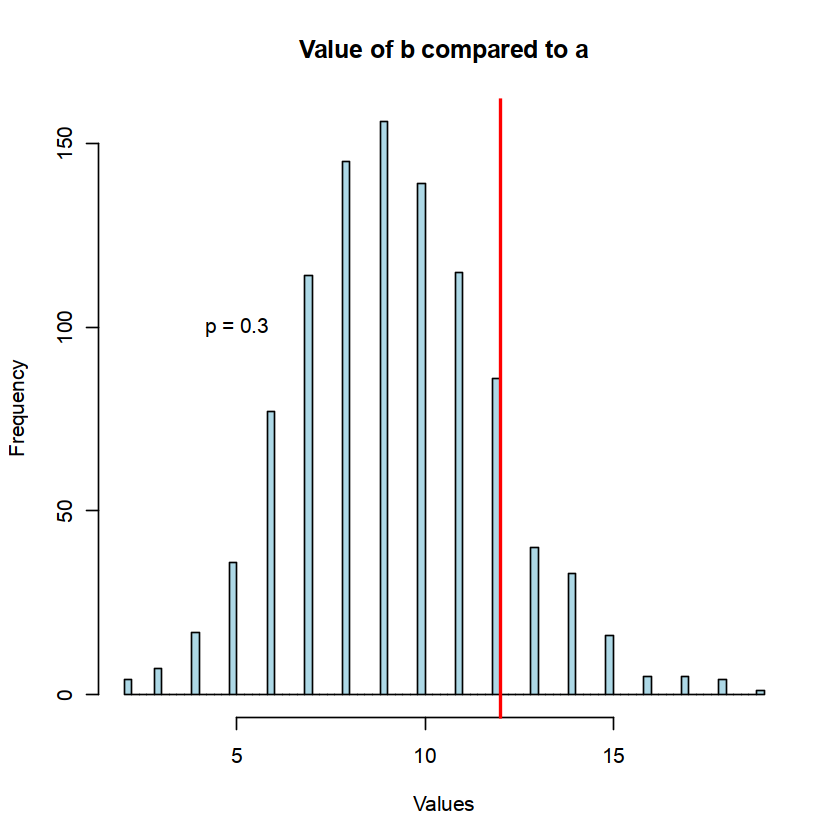

In [15]:
#pdf(file = "C2_diffgene_spechubs_random_test.pdf",width = 5,height = 5)
hist(C2_random_save, breaks = 100, col = "lightblue", main = "Value of b compared to a",
     xlab = "Values")
abline(v = length(C2_intersect_genes), col = "red", lwd = 2)
text(x = 5,y = 100,labels = paste0('p = ',round(pval,2)))
#dev.off()

In [16]:
z <- (length(C3_intersect_genes) - mean(C3_random_save)) / sd(C3_random_save)         # standardized value
pval3 <- 2 * (1 - pnorm(abs(z)))    # two-sided p-value
z; pval3

[1] 0.2712564

[1] 0.7861939

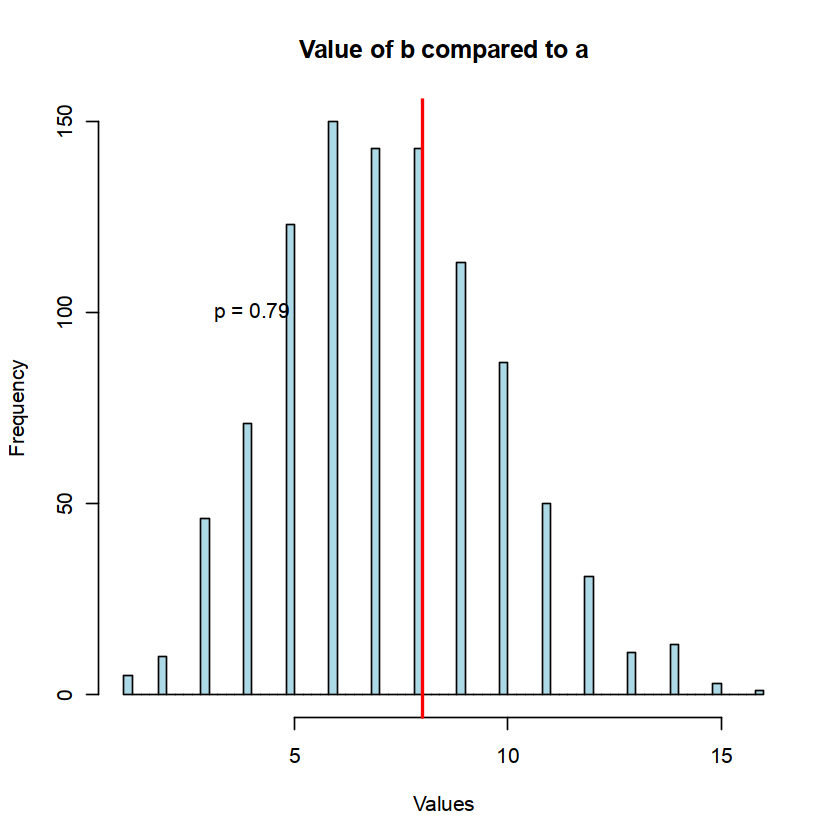

In [17]:
#pdf(file = "C3_diffgene_spechubs_random_test.pdf",width = 5,height = 5)
hist(C3_random_save, breaks = 100, col = "lightblue", main = "Value of b compared to a",
     xlab = "Values")
abline(v = length(C3_intersect_genes), col = "red", lwd = 2)
text(x = 4,y = 100,labels = paste0('p = ',round(pval3,2)))
#dev.off()